## 1. Imports y configuracion

In [5]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


## 2. Rutas del dataset

In [6]:
# Este bloque funciona si el notebook se ejecuta desde Project/ o desde la raiz del repo.
DATASET_ROOT = Path("Plant_disease_recognition_dataset")
if not DATASET_ROOT.exists():
    DATASET_ROOT = Path("Project") / "Plant_disease_recognition_dataset"

SPLIT_DIRS = {
    "train": DATASET_ROOT / "Train" / "Train",
    "validation": DATASET_ROOT / "Validation" / "Validation",
    "test": DATASET_ROOT / "Test" / "Test",
}

for split_name, split_path in SPLIT_DIRS.items():
    if not split_path.exists():
        raise FileNotFoundError(f"No se encontro la carpeta de {split_name}: {split_path}")
    print(f"{split_name}: {split_path}")

train: Plant_disease_recognition_dataset\Train\Train
validation: Plant_disease_recognition_dataset\Validation\Validation
test: Plant_disease_recognition_dataset\Test\Test


## 3. Revision del dataset: tamanos, clases, balance y formato

In [7]:
records = []

for split_name, split_path in SPLIT_DIRS.items():
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        for image_path in sorted(class_dir.iterdir()):
            if not image_path.is_file():
                continue

            with Image.open(image_path) as img:
                records.append(
                    {
                        "split": split_name,
                        "class": class_dir.name,
                        "path": str(image_path),
                        "extension": image_path.suffix.lower(),
                        "format": img.format,
                        "mode": img.mode,
                        "width": img.width,
                        "height": img.height,
                    }
                )

metadata = pd.DataFrame(records)

print(f"Imagenes totales: {len(metadata)}")
display(metadata.head())

Imagenes totales: 1532


,split,class,path,extension,format,mode,width,height
0,train,Healthy,Plant_disease_recognition_dataset\Train\Train\...,.jpg,JPEG,RGB,4000,3000
1,train,Healthy,Plant_disease_recognition_dataset\Train\Train\...,.jpg,JPEG,RGB,4000,2672
2,train,Healthy,Plant_disease_recognition_dataset\Train\Train\...,.jpg,JPEG,RGB,4000,2672
3,train,Healthy,Plant_disease_recognition_dataset\Train\Train\...,.jpg,JPEG,RGB,4000,2672
4,train,Healthy,Plant_disease_recognition_dataset\Train\Train\...,.jpg,JPEG,RGB,4000,2672


Imagenes por split:


,total
split,
test,150
train,1322
validation,60


Balance por clase:


class,Healthy,Powdery,Rust
split,,,
test,50,50,50
train,458,430,434
validation,20,20,20


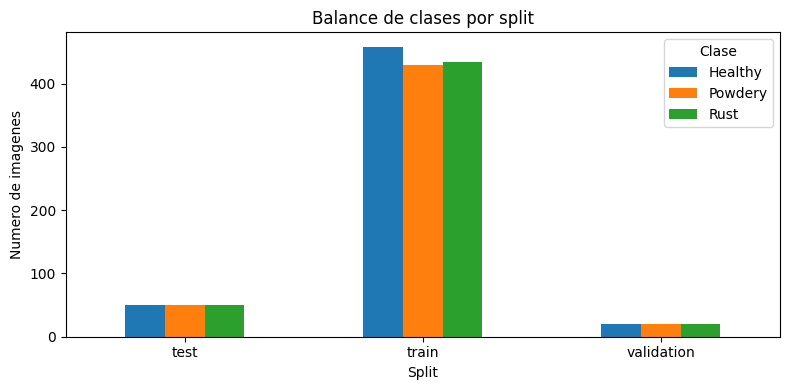

In [8]:
class_counts = metadata.groupby(["split", "class"]).size().unstack(fill_value=0)
split_counts = metadata.groupby("split").size().rename("total")

print("Imagenes por split:")
display(split_counts.to_frame())

print("Balance por clase:")
display(class_counts)

ax = class_counts.plot(kind="bar", figsize=(8, 4), rot=0)
ax.set_title("Balance de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Numero de imagenes")
ax.legend(title="Clase")
plt.tight_layout()
plt.show()

In [9]:
print("Formatos de archivo:")
display(metadata.groupby(["split", "extension", "format", "mode"]).size().rename("count").reset_index())

print("Tamanos mas frecuentes:")
display(
    metadata.assign(size=metadata["width"].astype(str) + "x" + metadata["height"].astype(str))
    .groupby(["split", "size"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["split", "count"], ascending=[True, False])
    .groupby("split")
    .head(10)
)

display(metadata[["width", "height"]].describe())

Formatos de archivo:


,split,extension,format,mode,count
0,test,.jpg,JPEG,RGB,150
1,train,.jpg,JPEG,RGB,1322
2,validation,.jpg,JPEG,RGB,60


Tamanos mas frecuentes:


,split,size,count
2,test,4000x2672,111
0,test,2592x1728,17
5,test,5184x3456,10
3,test,4000x3000,6
4,test,4608x3456,5
1,test,3901x2607,1
8,train,4000x2672,976
7,train,2592x1728,105
12,train,5184x3456,82
9,train,4000x3000,80


,width,height
count,1532.000000,1532.000000
mean,3986.058747,2702.447781
std,521.635395,385.260266
min,2421.000000,1728.000000
25%,4000.000000,2672.000000
50%,4000.000000,2672.000000
75%,4000.000000,2672.000000
max,5184.000000,3456.000000


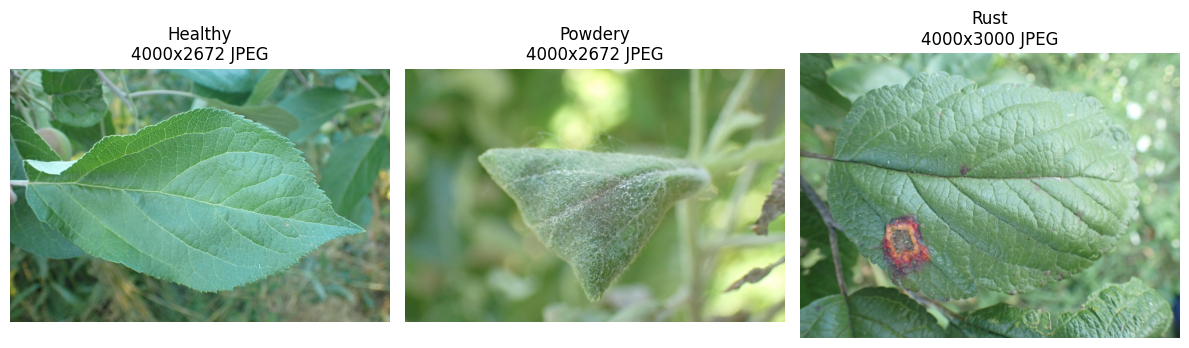

In [10]:
# Una imagen de ejemplo por clase en el split de entrenamiento.
sample_images = metadata[metadata["split"] == "train"].groupby("class").sample(n=1, random_state=SEED)

fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 4))
if len(sample_images) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, sample_images.iterrows()):
    with Image.open(row["path"]) as img:
        ax.imshow(img)
    ax.set_title(f"{row['class']}\n{row['width']}x{row['height']} {row['format']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Preparacion de datos

Para mantener el baseline simple e interpretable se usa solo `Resize` y `ToTensor`. No se aplica data augmentation, asi el resultado sirve como referencia minima.

In [11]:
IMG_SIZE = 128
BATCH_SIZE = 32

baseline_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.ImageFolder(root=SPLIT_DIRS["train"], transform=baseline_transform)
val_dataset = datasets.ImageFolder(root=SPLIT_DIRS["validation"], transform=baseline_transform)
test_dataset = datasets.ImageFolder(root=SPLIT_DIRS["test"], transform=baseline_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)
print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")

Clases: ['Healthy', 'Powdery', 'Rust']
Train: 1322 | Validation: 60 | Test: 150


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

images, labels = next(iter(train_loader))
print("Batch de imagenes:", images.shape)
print("Batch de etiquetas:", labels.shape)

Batch de imagenes: torch.Size([32, 3, 128, 128])
Batch de etiquetas: torch.Size([32])


## 7. Evaluacion final en test

In [16]:
@torch.no_grad()
def predict(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    total_loss = 0.0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)
        predictions = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total += batch_size

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

    return np.array(y_true), np.array(y_pred), total_loss / total


y_true, y_pred, test_loss = predict(model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

metrics_df = pd.DataFrame(
    [
        {
            "loss": test_loss,
            "accuracy": accuracy,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "f1_weighted": f1_weighted,
        }
    ]
)

display(metrics_df)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

,loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,0.865673,0.68,0.797395,0.68,0.668928,0.797395,0.68,0.668928


              precision    recall  f1-score   support

     Healthy     0.5217    0.9600    0.6761        50
     Powdery     0.9231    0.7200    0.8090        50
        Rust     0.9474    0.3600    0.5217        50

    accuracy                         0.6800       150
   macro avg     0.7974    0.6800    0.6689       150
weighted avg     0.7974    0.6800    0.6689       150



## 8. Matriz de confusion

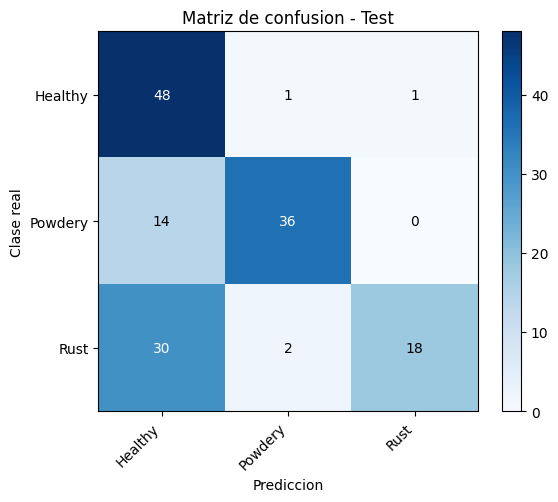

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax)

ax.set_title("Matriz de confusion - Test")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

threshold = cm.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        color = "white" if cm[i, j] > threshold else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

plt.tight_layout()
plt.show()